# Procurement & Sustainability Analytics Project


## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

In [2]:
np.random.seed(42)
random.seed(42)

## Create Country Dimension


In [3]:
## country table making 
countries = pd.DataFrame({
    "CountryID": range(1, 11),
    "CountryName": [
        "Czech Republic", "Germany", "Sweden", "Poland", "France",
        "Italy", "Netherlands", "Austria", "Spain", "Belgium"
    ],
    "Region": [
        "Central Europe", "Western Europe", "Northern Europe", "Central Europe", "Western Europe",
        "Southern Europe", "Western Europe", "Central Europe", "Southern Europe", "Western Europe"
    ]
})

countries

,CountryID,CountryName,Region
0,1,Czech Republic,Central Europe
1,2,Germany,Western Europe
2,3,Sweden,Northern Europe
3,4,Poland,Central Europe
4,5,France,Western Europe
5,6,Italy,Southern Europe
6,7,Netherlands,Western Europe
7,8,Austria,Central Europe
8,9,Spain,Southern Europe
9,10,Belgium,Western Europe


## Create Supplier Dimension

In [4]:

supplier_names = [
    "Nordic Supply", "GreenTech Components", "EuroParts", "Industrial Solutions",
    "Smart Logistics", "EcoMaterials", "Precision Tools", "Global Maintenance",
    "SteelPro", "Energy Systems"
]

suppliers = pd.DataFrame({
    "SupplierID": range(1, 501),
    "SupplierName": [random.choice(supplier_names) + " " + str(i) for i in range(1, 501)],
    "CountryID": np.random.randint(1, 11, 500),
    "Industry": np.random.choice(
        ["Manufacturing", "Logistics", "Maintenance", "Electronics", "Raw Materials"],
        500
    ),
    "ESGScore": np.random.randint(45, 100, 500),
    "SupplierStatus": np.random.choice(
        ["Active", "Active", "Active", "Under Review"],
        500
    )
})

suppliers["SupplierRating"] = np.where(
    suppliers["ESGScore"] >= 85,
    "A",
    np.where(
        suppliers["ESGScore"] >= 70,
        "B",
        np.where(
            suppliers["ESGScore"] >= 55,
            "C",
            "D"
        )
    )
)

suppliers.head()

,SupplierID,SupplierName,CountryID,Industry,ESGScore,SupplierStatus,SupplierRating
0,1,GreenTech Components 1,7,Manufacturing,77,Active,B
1,2,Nordic Supply 2,4,Manufacturing,91,Under Review,A
2,3,Smart Logistics 3,8,Manufacturing,84,Active,B
3,4,Industrial Solutions 4,5,Electronics,87,Active,A
4,5,Industrial Solutions 5,7,Manufacturing,56,Under Review,C


##  Data Validation


In [5]:
suppliers.shape

(500, 7)

In [6]:
suppliers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SupplierID      500 non-null    int64 
 1   SupplierName    500 non-null    object
 2   CountryID       500 non-null    int32 
 3   Industry        500 non-null    object
 4   ESGScore        500 non-null    int32 
 5   SupplierStatus  500 non-null    object
 6   SupplierRating  500 non-null    object
dtypes: int32(2), int64(1), object(4)
memory usage: 23.6+ KB


In [7]:
suppliers.isnull().sum()

SupplierID        0
SupplierName      0
CountryID         0
Industry          0
ESGScore          0
SupplierStatus    0
SupplierRating    0
dtype: int64

In [8]:
suppliers["SupplierRating"].value_counts()

SupplierRating
A    147
B    141
C    131
D     81
Name: count, dtype: int64

In [9]:
suppliers["ESGScore"].describe()

count    500.000000
mean      73.434000
std       15.787721
min       45.000000
25%       61.000000
50%       74.000000
75%       87.000000
max       99.000000
Name: ESGScore, dtype: float64

<Axes: >

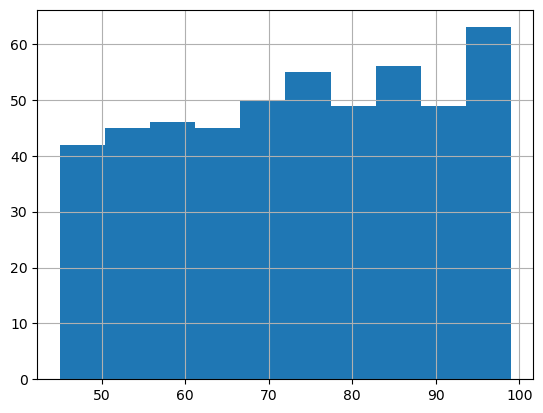

In [10]:
suppliers["ESGScore"].hist(bins=10)

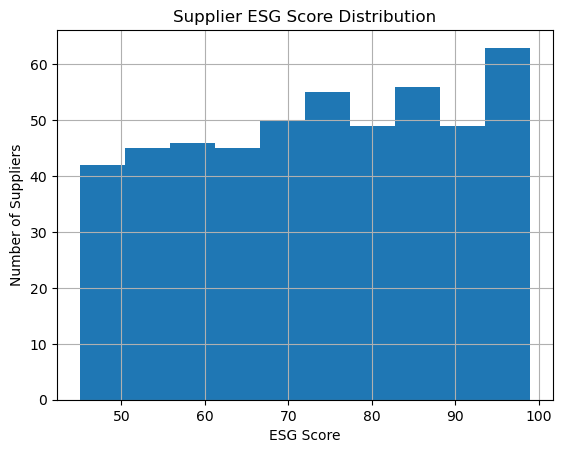

In [11]:
import matplotlib.pyplot as plt

suppliers["ESGScore"].hist(bins=10)

plt.title("Supplier ESG Score Distribution")
plt.xlabel("ESG Score")
plt.ylabel("Number of Suppliers")

plt.show()

## Create Product Dimension

In [12]:
product_categories = [
    "Raw Materials",
    "Electronic Components",
    "Spare Parts",
    "Maintenance Services",
    "Logistics Services",
    "Industrial Tools",
    "Safety Equipment",
    "Packaging Materials"
]

product_categories

['Raw Materials',
 'Electronic Components',
 'Spare Parts',
 'Maintenance Services',
 'Logistics Services',
 'Industrial Tools',
 'Safety Equipment',
 'Packaging Materials']

In [13]:
product_names = [
    "Steel Sheet", "Aluminum Plate", "Copper Wire", "Industrial Plastic", "Rubber Seal",
    "Pressure Sensor", "Temperature Sensor", "Control Unit", "PLC Module", "Circuit Board",
    "Air Filter", "Oil Filter", "Bearing", "Control Valve", "Compressor Seal",
    "Maintenance Service", "Calibration Service", "Repair Service", "Inspection Service", "Cleaning Service",
    "Transport Service", "Warehouse Service", "Customs Service", "Packaging Service", "Distribution Service",
    "Drill", "Cutting Tool", "Torque Wrench", "Grinding Wheel", "Measuring Tool",
    "Safety Gloves", "Helmet", "Protective Glasses", "Safety Shoes", "Ear Protection",
    "Cardboard Box", "Wooden Pallet", "Plastic Container", "Wrapping Film", "Label"
]

In [14]:
len(product_names)

40

In [15]:
products = pd.DataFrame({
    "ProductID": range(1, 101),
    "ProductName": [random.choice(product_names) + " " + str(i) for i in range(1, 101)],
    "Category": np.random.choice(product_categories, 100),
    "StandardUnitPrice": np.random.randint(100, 5000, 100)
})

products.head()

,ProductID,ProductName,Category,StandardUnitPrice
0,1,Air Filter 1,Electronic Components,3038
1,2,Pressure Sensor 2,Spare Parts,4028
2,3,Inspection Service 3,Industrial Tools,2140
3,4,Protective Glasses 4,Logistics Services,127
4,5,Label 5,Packaging Materials,2213


In [16]:
products["Category"].value_counts()

Category
Maintenance Services     16
Electronic Components    15
Industrial Tools         14
Logistics Services       14
Safety Equipment         12
Spare Parts              10
Packaging Materials      10
Raw Materials             9
Name: count, dtype: int64

## Define Warehouse Locations

In [17]:
warehouses = [
    "Prague Warehouse",
    "Brno Warehouse",
    "Ostrava Warehouse",
    "Plzen Warehouse",
    "Olomouc Warehouse",
    "Liberec Warehouse",
    "Pardubice Warehouse",
    "Ceske Budejovice Warehouse",
    "Hradec Kralove Warehouse",
    "Zlin Warehouse"
]

warehouses

['Prague Warehouse',
 'Brno Warehouse',
 'Ostrava Warehouse',
 'Plzen Warehouse',
 'Olomouc Warehouse',
 'Liberec Warehouse',
 'Pardubice Warehouse',
 'Ceske Budejovice Warehouse',
 'Hradec Kralove Warehouse',
 'Zlin Warehouse']

## Create Purchase Orders Fact Table

In [18]:
num_orders = 10000

num_orders

10000

In [19]:
# Define date range for purchase orders

start_date = datetime(2023, 1, 1)
end_date = datetime(2025, 12, 31)

date_range = (end_date - start_date).days

In [20]:
# Define warehouse probability distribution

warehouse_probabilities = [
    0.22,  # Prague Warehouse
    0.20,  # Brno Warehouse
    0.15,  # Ostrava Warehouse
    0.10,  # Plzen Warehouse
    0.08,  # Olomouc Warehouse
    0.07,  # Liberec Warehouse
    0.06,  # Pardubice Warehouse
    0.05,  # Ceske Budejovice Warehouse
    0.04,  # Hradec Kralove Warehouse
    0.03   # Zlin Warehouse
]

In [21]:
# Create purchase orders fact table

purchase_orders = pd.DataFrame({
    "OrderID": range(1, num_orders + 1),
    "SupplierID": np.random.randint(1, 501, num_orders),
    "ProductID": np.random.randint(1, 101, num_orders),
    "OrderDate": [
        start_date + timedelta(days=random.randint(0, date_range))
        for _ in range(num_orders)
    ],
    "Warehouse": np.random.choice(
        warehouses,
        size=num_orders,
        p=warehouse_probabilities
    ),
    "Quantity": np.random.randint(1, 200, num_orders),
    "UnitPrice": np.random.randint(100, 5000, num_orders)
})

purchase_orders["Amount"] = purchase_orders["Quantity"] * purchase_orders["UnitPrice"]

purchase_orders["PaymentStatus"] = np.random.choice(
    ["Paid", "Pending", "Overdue"],
    size=num_orders,
    p=[0.68, 0.22, 0.10]
)

purchase_orders.head()

,OrderID,SupplierID,ProductID,OrderDate,Warehouse,Quantity,UnitPrice,Amount,PaymentStatus
0,1,498,77,2024-03-27,Liberec Warehouse,88,1696,149248,Paid
1,2,192,27,2025-09-26,Olomouc Warehouse,104,1045,108680,Paid
2,3,454,78,2024-03-25,Prague Warehouse,124,1387,171988,Paid
3,4,63,24,2024-07-12,Prague Warehouse,185,367,67895,Paid
4,5,73,67,2025-06-11,Pardubice Warehouse,34,534,18156,Pending


In [22]:
purchase_orders.shape

(10000, 9)

In [23]:
purchase_orders["Warehouse"].value_counts()

Warehouse
Prague Warehouse              2194
Brno Warehouse                2082
Ostrava Warehouse             1450
Plzen Warehouse               1022
Olomouc Warehouse              802
Liberec Warehouse              665
Pardubice Warehouse            547
Ceske Budejovice Warehouse     533
Hradec Kralove Warehouse       397
Zlin Warehouse                 308
Name: count, dtype: int64

In [24]:
purchase_orders.shape

(10000, 9)

In [25]:
purchase_orders.isnull().sum()

OrderID          0
SupplierID       0
ProductID        0
OrderDate        0
Warehouse        0
Quantity         0
UnitPrice        0
Amount           0
PaymentStatus    0
dtype: int64

In [26]:
purchase_orders["Warehouse"].value_counts()

Warehouse
Prague Warehouse              2194
Brno Warehouse                2082
Ostrava Warehouse             1450
Plzen Warehouse               1022
Olomouc Warehouse              802
Liberec Warehouse              665
Pardubice Warehouse            547
Ceske Budejovice Warehouse     533
Hradec Kralove Warehouse       397
Zlin Warehouse                 308
Name: count, dtype: int64

In [27]:
purchase_orders["PaymentStatus"].value_counts()

PaymentStatus
Paid       6762
Pending    2182
Overdue    1056
Name: count, dtype: int64

## Create Deliveries Fact Table

In [28]:
# Create deliveries table

deliveries = purchase_orders[
    ["OrderID", "SupplierID", "OrderDate"]
].copy()

deliveries.head()

,OrderID,SupplierID,OrderDate
0,1,498,2024-03-27
1,2,192,2025-09-26
2,3,454,2024-03-25
3,4,63,2024-07-12
4,5,73,2025-06-11


In [29]:
deliveries["DeliveryID"] = range(1, num_orders + 1)

deliveries.head()

,OrderID,SupplierID,OrderDate,DeliveryID
0,1,498,2024-03-27,1
1,2,192,2025-09-26,2
2,3,454,2024-03-25,3
3,4,63,2024-07-12,4
4,5,73,2025-06-11,5


In [30]:
deliveries["PlannedDate"] = (
    deliveries["OrderDate"] +
    pd.to_timedelta(
        np.random.randint(5, 30, num_orders),
        unit="D"
    )
)

deliveries.head()

,OrderID,SupplierID,OrderDate,DeliveryID,PlannedDate
0,1,498,2024-03-27,1,2024-04-11
1,2,192,2025-09-26,2,2025-10-23
2,3,454,2024-03-25,3,2024-04-10
3,4,63,2024-07-12,4,2024-07-17
4,5,73,2025-06-11,5,2025-06-18


In [31]:
# Add ESG score to deliveries table

deliveries = deliveries.merge(
    suppliers[["SupplierID", "ESGScore"]],
    on="SupplierID",
    how="left"
)

deliveries.head()

,OrderID,SupplierID,OrderDate,DeliveryID,PlannedDate,ESGScore
0,1,498,2024-03-27,1,2024-04-11,56
1,2,192,2025-09-26,2,2025-10-23,92
2,3,454,2024-03-25,3,2024-04-10,57
3,4,63,2024-07-12,4,2024-07-17,71
4,5,73,2025-06-11,5,2025-06-18,50


In [32]:
deliveries.isnull().sum()

OrderID        0
SupplierID     0
OrderDate      0
DeliveryID     0
PlannedDate    0
ESGScore       0
dtype: int64

In [33]:
def generate_actual_date(row):

    if row["ESGScore"] >= 80:
        delay = np.random.choice(
            [-3, -2, -1, 0, 1],
            p=[0.20, 0.25, 0.25, 0.20, 0.10]
        )

    elif row["ESGScore"] >= 65:
        delay = np.random.choice(
            [-2, -1, 0, 1, 2],
            p=[0.15, 0.25, 0.30, 0.20, 0.10]
        )

    else:
        delay = np.random.choice(
            [-1, 0, 1, 2, 3],
            p=[0.10, 0.35, 0.30, 0.15, 0.10]
        )

    return row["PlannedDate"] + timedelta(days=int(delay))

In [34]:
deliveries["ActualDate"] = deliveries.apply(generate_actual_date, axis=1)

deliveries["DelayDays"] = (
    deliveries["ActualDate"] - deliveries["PlannedDate"]
).dt.days

deliveries["DeliveryStatus"] = np.where(
    deliveries["ActualDate"] <= deliveries["PlannedDate"],
    "On Time",
    "Late"
)

In [35]:
deliveries["DeliveryStatus"].value_counts()

DeliveryStatus
On Time    6991
Late       3009
Name: count, dtype: int64

In [36]:
deliveries["DeliveryStatus"].value_counts()

DeliveryStatus
On Time    6991
Late       3009
Name: count, dtype: int64

## Create Sustainability Dimension

In [37]:
sustainability = suppliers[
    ["SupplierID", "ESGScore"]
].copy()

sustainability.head()

,SupplierID,ESGScore
0,1,77
1,2,91
2,3,84
3,4,87
4,5,56


In [38]:
# CO2 Emissions adding
sustainability["CO2EmissionTons"] = np.where(
    sustainability["ESGScore"] >= 80,
    np.random.randint(50, 300, len(sustainability)),
    np.where(
        sustainability["ESGScore"] >= 65,
        np.random.randint(250, 700, len(sustainability)),
        np.random.randint(700, 1500, len(sustainability))
    )
)

sustainability.head()

,SupplierID,ESGScore,CO2EmissionTons
0,1,77,569
1,2,91,241
2,3,84,211
3,4,87,209
4,5,56,820


In [39]:
sustainability["SustainabilityRisk"] = np.where(
    sustainability["ESGScore"] >= 80,
    "Low",
    np.where(
        sustainability["ESGScore"] >= 65,
        "Medium",
        "High"
    )
)

sustainability.head()

,SupplierID,ESGScore,CO2EmissionTons,SustainabilityRisk
0,1,77,569,Medium
1,2,91,241,Low
2,3,84,211,Low
3,4,87,209,Low
4,5,56,820,High


In [40]:
sustainability["SustainabilityRisk"].value_counts()

SustainabilityRisk
Low       195
High      158
Medium    147
Name: count, dtype: int64

In [41]:
countries.shape

(10, 3)

In [42]:
suppliers.shape

(500, 7)

In [43]:
suppliers.shape

(500, 7)

In [44]:
products.shape

(100, 4)

In [45]:
purchase_orders.shape

(10000, 9)

In [46]:
deliveries.shape

(10000, 9)

In [47]:
sustainability.shape

(500, 4)

## Export Data to CSV

In [48]:
countries.to_csv("countries.csv", index=False)

In [49]:
suppliers.to_csv("suppliers.csv", index=False)

In [50]:
products.to_csv("products.csv", index=False)

In [51]:
purchase_orders.to_csv("purchase_orders.csv", index=False)

In [52]:
deliveries.to_csv("deliveries.csv", index=False)

In [53]:
sustainability.to_csv("sustainability.csv", index=False)

In [54]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Atlas_Copco_Data_Generation.ipynb',
 'countries.csv',
 'deliveries.csv',
 'products.csv',
 'purchase_orders.csv',
 'suppliers.csv',
 'sustainability.csv']

In [55]:
import os

os.getcwd()

'C:\\Users\\xayal\\atlas_cpc'

In [56]:
import os

os.listdir(r"C:\Users\xayal\atlas_cpc")

['.ipynb_checkpoints',
 'Atlas_Copco_Data_Generation.ipynb',
 'countries.csv',
 'deliveries.csv',
 'products.csv',
 'purchase_orders.csv',
 'suppliers.csv',
 'sustainability.csv']

In [57]:
import os

for file in os.listdir():
    print(file)

.ipynb_checkpoints
Atlas_Copco_Data_Generation.ipynb
countries.csv
deliveries.csv
products.csv
purchase_orders.csv
suppliers.csv
sustainability.csv
